# Temporal Distribution by Rescaling

In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [25]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

## Rescaling

In [26]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(18064, 17)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'edit_date', 'pinned', 'post_author', 'sender_id', 'sender_username',
       'sender_name', 'has_media', 'reactions', 'subgroup', 'topic_name',
       'reply'],
      dtype='object')


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,None,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [27]:
# Convert date to datetime and sort by time
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Total messages: 18064
Date range: 2024-10-30 12:39:24+00:00 to 2025-11-10 11:06:47+00:00


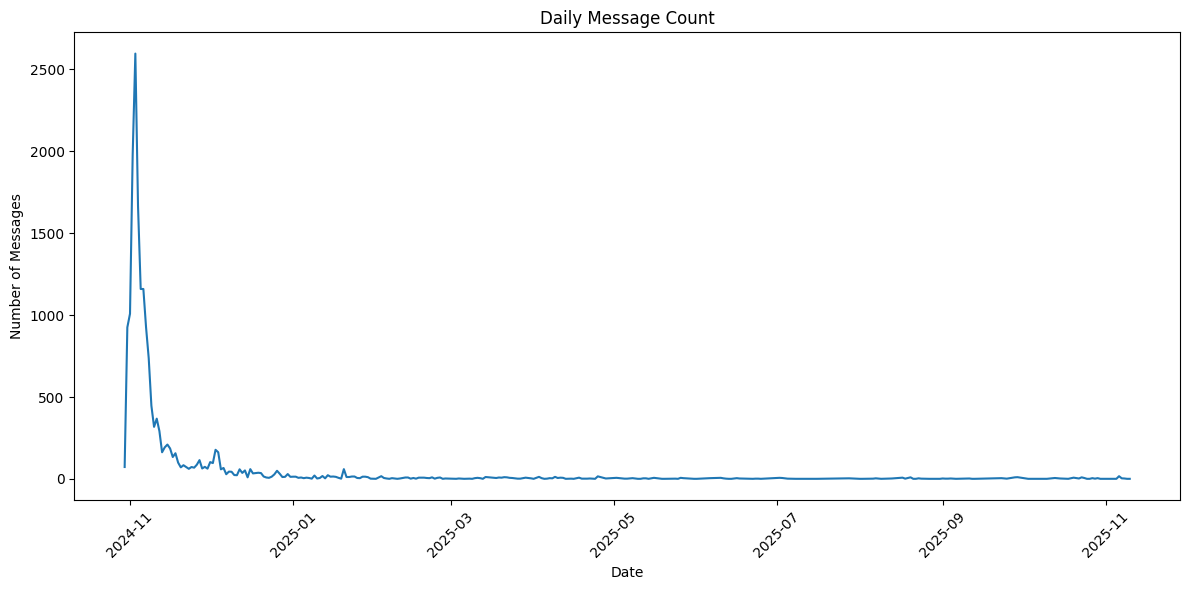

In [28]:
# Plot the distribution of messages over time (daily)
plt.figure(figsize=(12, 6))
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()
daily_counts.plot(kind='line')
plt.title('Daily Message Count')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of messages until Jan 1st 2025

Total messages until Jan 1st 2025: 17044
Total messages sent in total (until Nov 10th 2025): 18064
Date range: 2024-10-30 12:39:24+00:00 to 2024-12-31 22:50:08+00:00


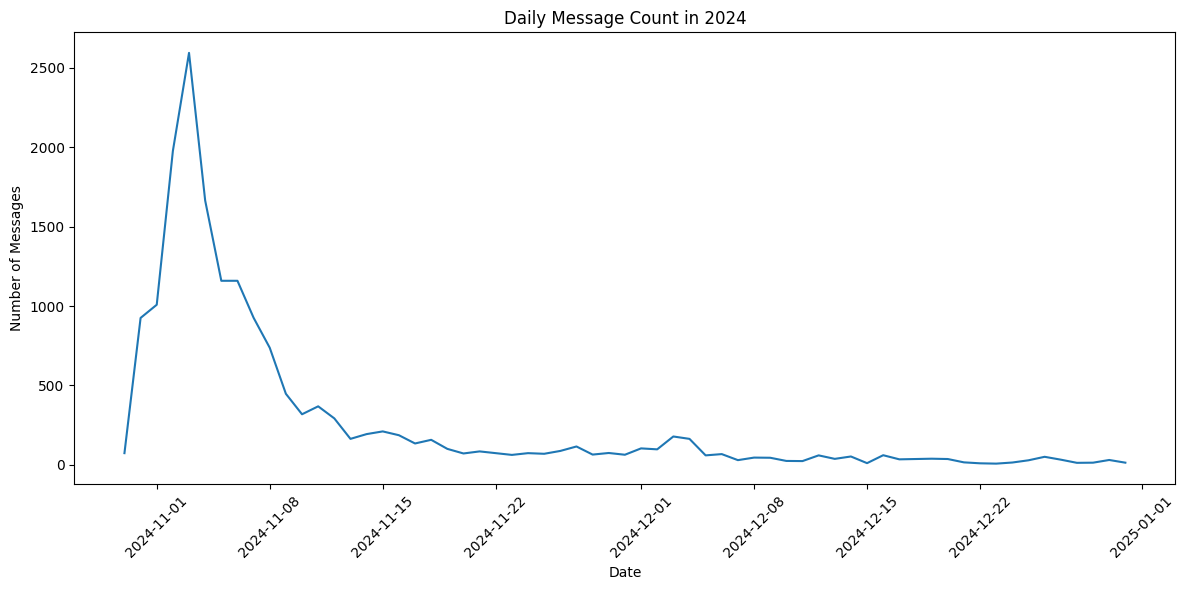

In [29]:
# Create new dataframe with messages until Jan 1st 2025
df_2024 = df[df['date'] < '2025-01-01'].copy()
print(f"Total messages until Jan 1st 2025: {len(df_2024)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_2024['date'].min()} to {df_2024['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_2024['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Calculate waiting times (inter-arrival times) between consecutive messages

# Calculate time differences in seconds
df_2024['waiting_time'] = df_2024['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times = df_2024['waiting_time'].dropna()
waiting_times = waiting_times[waiting_times > 0]

print(f"Number of waiting times: {len(waiting_times)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times.mean():.2f} seconds ({waiting_times.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times.median():.2f} seconds ({waiting_times.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times.min():.2f} seconds")
print(f"  Max: {waiting_times.max():.2f} seconds ({waiting_times.max()/3600:.2f} hours)")

Number of waiting times: 16222
Statistics:
  Mean: 332.48 seconds (5.54 minutes)
  Median: 35.00 seconds (0.58 minutes)
  Min: 1.00 seconds
  Max: 64566.00 seconds (17.93 hours)


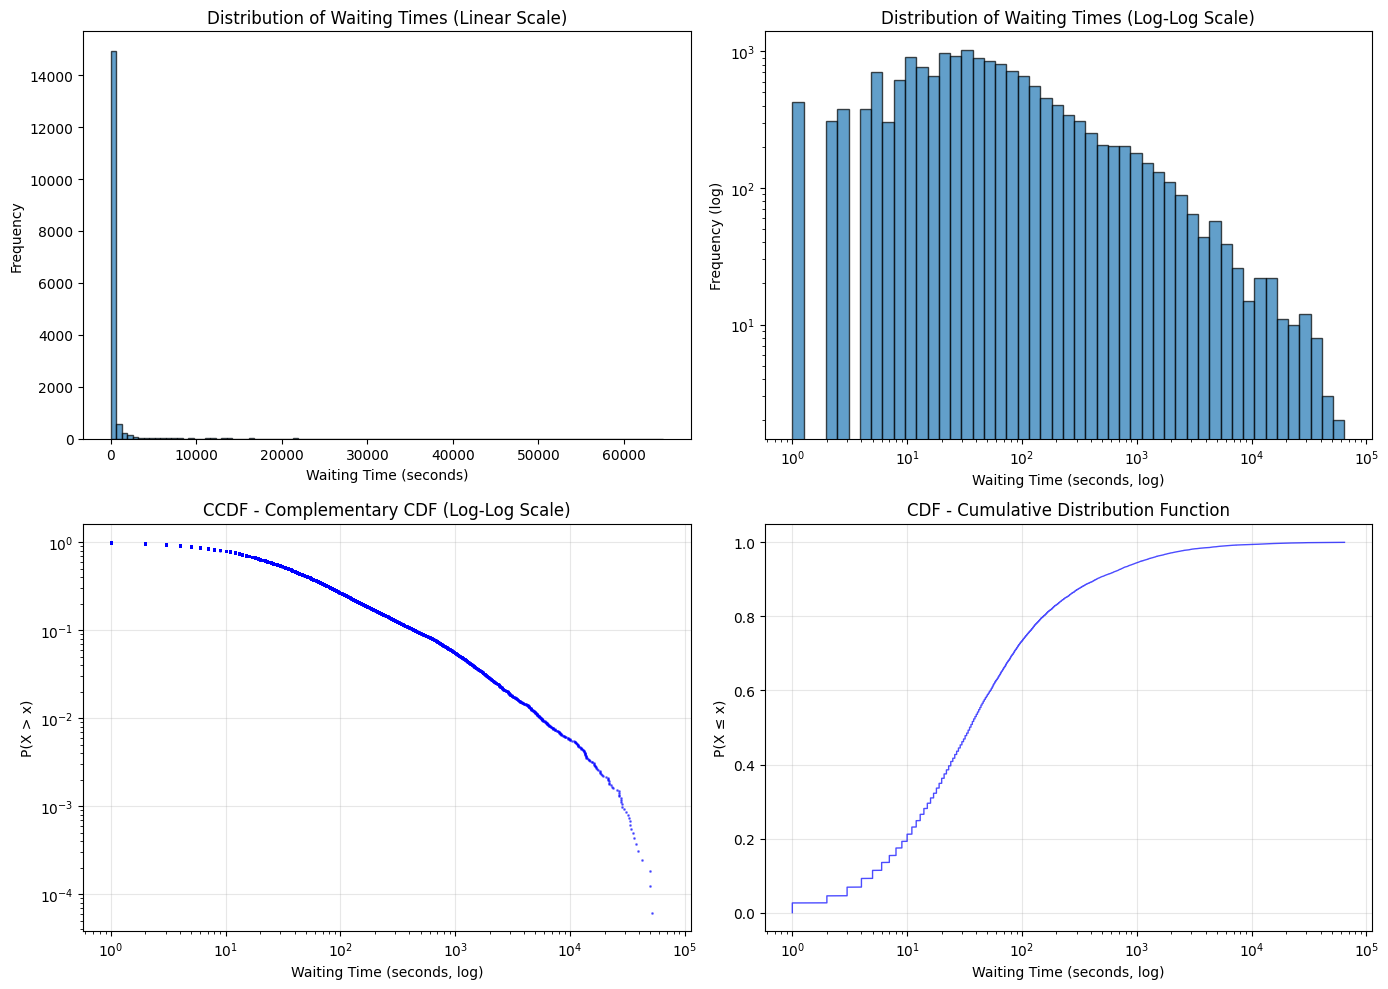

In [31]:
# Visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times = np.sort(waiting_times)
ccdf = 1 - np.arange(1, len(sorted_times) + 1) / len(sorted_times)
axes[1, 0].plot(sorted_times, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times, np.arange(1, len(sorted_times) + 1) / len(sorted_times), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fit to truncated power law

TRUNCATED POWER LAW FIT RESULTS
alpha: 1.6055
lambda: 0.000038
xmin: 53.0000
sigma: nan
Data points above xmin: 6535 / 16222 (40.28%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 9.4052, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 4.2500, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 22.9279, p = 0.0000
  ✓ Truncated power law is significantly better


Assuming nested distributions



KS distance (truncated power law): 0.0118
✓ Good fit (KS < 0.1)


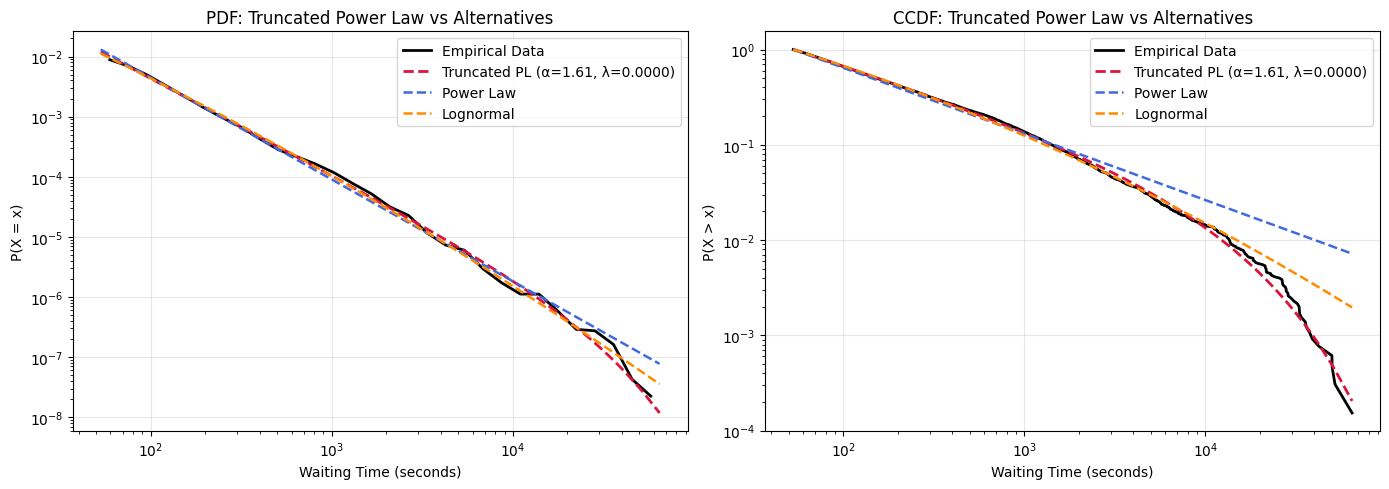

KS statistic (tail): 0.011910
KS p-value (tail): 0.309611


In [32]:
import powerlaw

# Prepare data
data_tpl = np.asarray(waiting_times.values, dtype=float)
data_tpl = data_tpl[np.isfinite(data_tpl)]
data_tpl = data_tpl[data_tpl > 0]

# Fit using powerlaw package
fit_tpl = powerlaw.Fit(data_tpl, discrete=False, verbose=False)
tpl = fit_tpl.truncated_power_law

alpha_tpl = getattr(tpl, "alpha", np.nan)
lambda_tpl = getattr(tpl, "Lambda", np.nan)
xmin_tpl = getattr(tpl, "xmin", np.nan)
sigma_tpl = getattr(tpl, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl:.4f}")
print(f"lambda: {lambda_tpl:.6f}")
print(f"xmin: {xmin_tpl:.4f}")
print(f"sigma: {sigma_tpl:.4f}")
n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
if len(tail_tpl) == 0:
    ks_tpl = float("nan")
else:
    empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
    try:
        model_cdf_tpl = tpl.cdf(tail_tpl)
    except Exception:
        model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
    ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl:.4f}")
if np.isnan(ks_tpl):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl:.6f}")
print(f"KS p-value (tail): {ks_p_tpl:.6g}")
print("="*70)

### Time-rescaling theorem

*Put text explaining what I am doing*

In [33]:
# Filter waiting times that are >= xmin
tail_mask = waiting_times >= xmin_tpl
tail_waits = waiting_times[tail_mask]

# Compute F(w) using the model's CDF
F_vals = tpl.cdf(tail_waits)          # values in [0,1]

# Transform to τ = -ln(1-F)
tau = -np.log(1 - F_vals)

# Compute z = F(w) for uniformity checks
z_vals = F_vals

Check exponential distribution of $\tau$

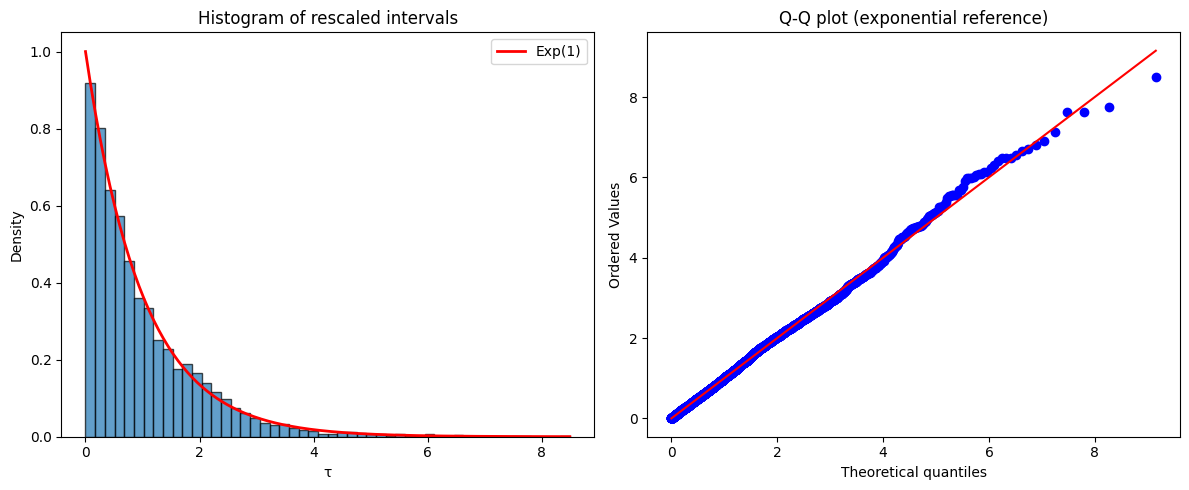

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(tau, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0, max(tau), 200)
axes[0].plot(x, stats.expon.pdf(x, scale=1), 'r-', lw=2, label='Exp(1)')
axes[0].set_xlabel('τ')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram of rescaled intervals')
axes[0].legend()

# QQ‑plot against exponential
stats.probplot(tau, dist=stats.expon, plot=axes[1])
axes[1].set_title('Q‑Q plot (exponential reference)')

plt.tight_layout()
plt.show()

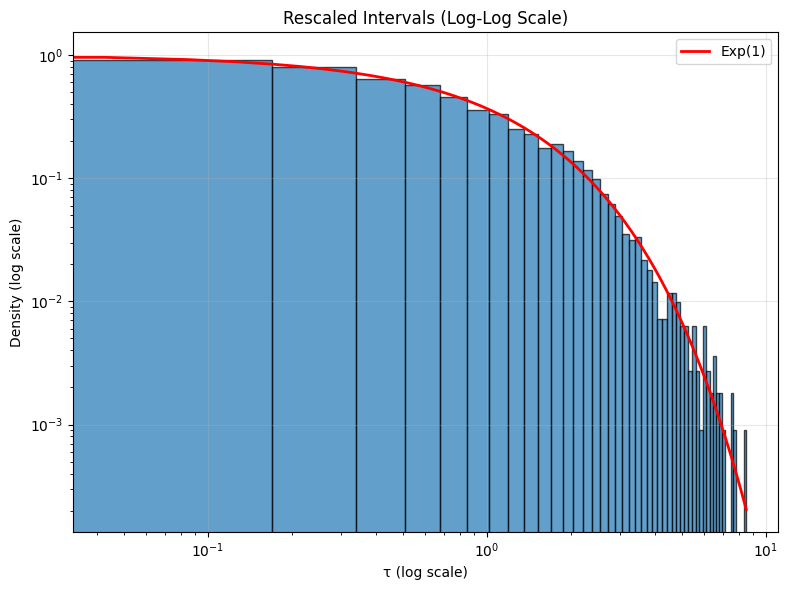

In [35]:
# Plot in log-log scale rescaled histogram
plt.figure(figsize=(8, 6))
plt.hist(tau, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0, max(tau), 200)
plt.plot(x, stats.expon.pdf(x, scale=1), 'r-', lw=2, label='Exp(1)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('τ (log scale)')
plt.ylabel('Density (log scale)')
plt.title('Rescaled Intervals (Log-Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [36]:
ks_stat, ks_p = stats.kstest(tau, 'expon', args=(0, 1))
print(f"KS test for exponential(1): statistic = {ks_stat:.4f}, p = {ks_p:.4f}")

KS test for exponential(1): statistic = 0.0119, p = 0.3096


### Universal Scaling Law (from Lab 1 & P.Set A from Experimental Techniques)
Ask Emanuele if this is correct.

TRUNCATED POWER LAW FIT RESULTS (RESCALED)
alpha: 1.6055
lambda: 0.012494
xmin: 0.1594
sigma: nan


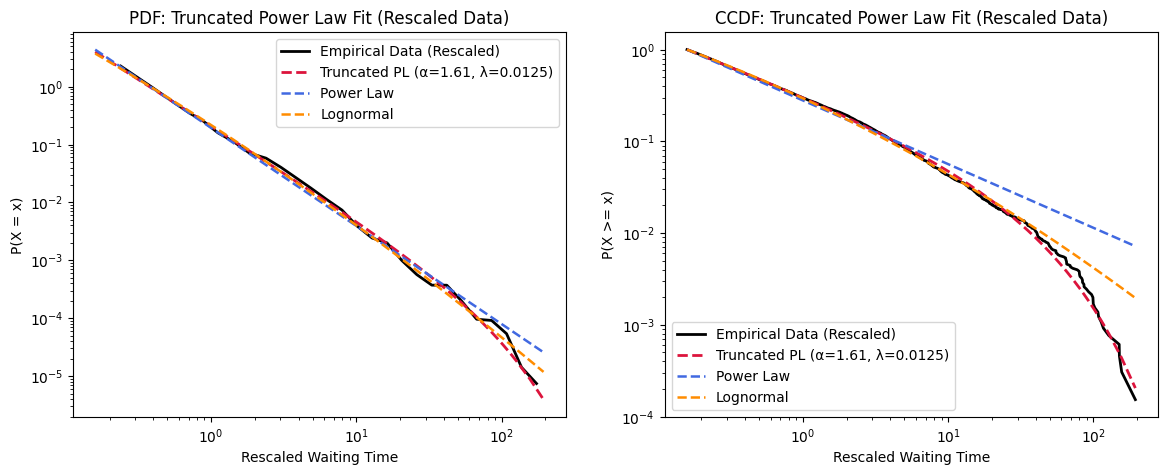

In [37]:
# Rescale the values of the waiting times using the average of them.
waiting_times_rescaled = waiting_times / waiting_times.mean()

# Fit to truncated power law again with rescaled data
data_tpl_rescaled = np.asarray(waiting_times_rescaled.values, dtype=float)
data_tpl_rescaled = data_tpl_rescaled[np.isfinite(data_tpl_rescaled)]
data_tpl_rescaled = data_tpl_rescaled[data_tpl_rescaled > 0]
fit_tpl_rescaled = powerlaw.Fit(data_tpl_rescaled, discrete=False, verbose=False)
tpl_rescaled = fit_tpl_rescaled.truncated_power_law
alpha_tpl_rescaled = getattr(tpl_rescaled, "alpha", np.nan)
lambda_tpl_rescaled = getattr(tpl_rescaled, "Lambda", np.nan)
xmin_tpl_rescaled = getattr(tpl_rescaled, "xmin", np.nan)
sigma_tpl_rescaled = getattr(tpl_rescaled, "sigma", np.nan)
print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS (RESCALED)")
print("="*70)
print(f"alpha: {alpha_tpl_rescaled:.4f}")
print(f"lambda: {lambda_tpl_rescaled:.6f}")
print(f"xmin: {xmin_tpl_rescaled:.4f}")
print(f"sigma: {sigma_tpl_rescaled:.4f}")

# Plot rescaled data and fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_tpl_rescaled.plot_pdf(color='black', linewidth=2, label='Empirical Data (Rescaled)', ax=axes[0])
tpl_rescaled.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_rescaled:.2f}, λ={lambda_tpl_rescaled:.4f})', ax=axes[0]
 ) 
fit_tpl_rescaled.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl_rescaled.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=
1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Rescaled Waiting Time')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law Fit (Rescaled Data)')
axes[0].legend()
fit_tpl_rescaled.plot_ccdf(color='black', linewidth=2, label='Empirical Data (Rescaled)', ax=axes[1])
tpl_rescaled.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_rescaled:.2f}, λ={lambda_tpl_rescaled:.4f})', ax=axes[1]
 ) 
fit_tpl_rescaled.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl_rescaled.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Rescaled Waiting Time')
axes[1].set_ylabel('P(X >= x)')
axes[1].set_title('CCDF: Truncated Power Law Fit (Rescaled Data)')
axes[1].legend()


I cannot see the difference, ask Emanuele about it.

## Rescaling by channel

In [38]:
# Check the names of the channels.
print(df_2024['topic_name'].unique()) 

['Discusión general' 'Bienvenid@s a la Red de Voluntari@s (leed primero)'
 'Transporte de personas a Comunidad Valenciana'
 'Grupos de Acción Voluntarios en Terreno' 'Asistencia Jurídica/Seguros'
 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)'
 'Asistencia animales compañia y otros'
 'Asistencia Informática/Soporte EAT'
 'Logística Interna Valencia(puntos de recepción)' 'Ayuda de Empresas'
 'Investigación Ciudadana: Responsabilidades Políticas'
 'Asistencia a Voluntarios (Comida y Acogida))'
 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)'
 'Material Video/Fotográfico' 'Webs Esenciales'
 'Mensajes de Ayuda (Ofrezco/Necesito)'
 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)'
 'Viviendas Edificación , Muebles y Acondicionamiento']


In [39]:
# Retrieve the data from the different channels
waiting_times_general = df_2024[df_2024['topic_name'] == 'Discusión general']['waiting_time']
waiting_times_bienvenidos = df_2024[df_2024['topic_name'] == 'Bienvenid@s a la Red de Voluntari@s (leed primero)']['waiting_time']
waiting_times_tranporte = df_2024[df_2024['topic_name'] == 'Transporte de personas a Comunidad Valenciana']['waiting_time']
waiting_times_grupos_accion = df_2024[df_2024['topic_name'] == 'Grupos de Acción Voluntarios en Terreno']['waiting_time']
waiting_times_juridica = df_2024[df_2024['topic_name'] == 'Asistencia Jurídica/Seguros']['waiting_time']
waiting_times_tecnica = df_2024[df_2024['topic_name'] == 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)']['waiting_time']
waiting_times_animales = df_2024[df_2024['topic_name'] == 'Asistencia animales compañia y otros']['waiting_time']
waiting_times_informatica = df_2024[df_2024['topic_name'] == 'Asistencia Informática/Soporte EAT']['waiting_time']
waiting_times_logistica = df_2024[df_2024['topic_name'] == 'Logística Interna Valencia(puntos de recepción)']['waiting_time']
waiting_times_ayudaempresas = df_2024[df_2024['topic_name'] == 'Ayuda de Empresas']['waiting_time']
waiting_times_investigacion = df_2024[df_2024['topic_name'] == 'Investigación Ciudadana: Responsabilidades Políticas']['waiting_time']
waiting_times_asistencia_voluntarios = df_2024[df_2024['topic_name'] == 'Asistencia a Voluntarios (Comida y Acogida))']['waiting_time']
waiting_times_asistencia_vulnerables = df_2024[df_2024['topic_name'] == 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)']['waiting_time']
waiting_times_material = df_2024[df_2024['topic_name'] == 'Material Video/Fotográfico']['waiting_time']
waiting_times_webs = df_2024[df_2024['topic_name'] == 'Webs Esenciales']['waiting_time']
waiting_times_mensajes_ayuda = df_2024[df_2024['topic_name'] == 'Mensajes de Ayuda (Ofrezco/Necesito)']['waiting_time']
waiting_times_voluntarios_fuera = df_2024[df_2024['topic_name'] == 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)']['waiting_time']
waiting_times_viviendas = df_2024[df_2024['topic_name'] == 'Viviendas Edificación , Muebles y Acondicionamiento']['waiting_time']




In [40]:
# Define a consistent color palette for all channels
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Using tab20 colormap which provides 20 distinct colors
tab20 = cm.get_cmap('tab20')
channel_colors = {
    'General': tab20(0),
    'Bienvenidos': tab20(1),
    'Transporte': tab20(2),
    'Grupos de Acción': tab20(3),
    'Jurídica': tab20(4),
    'Técnica': tab20(5),
    'Animales': tab20(6),
    'Informática': tab20(7),
    'Logística': tab20(8),
    'Ayuda a Empresas': tab20(9),
    'Investigación': tab20(10),
    'Asistencia a Voluntarios': tab20(11),
    'Asistencia a Grupos Vulnerables': tab20(12),
    'Material': tab20(13),
    'Webs': tab20(14),
    'Mensajes de Ayuda': tab20(15),
    'Voluntarios de Fuera': tab20(16),
    'Viviendas': tab20(17)
}

print("Color palette created with 18 distinct colors for all channels")

Color palette created with 18 distinct colors for all channels


C:\Users\Usuario\AppData\Local\Temp\ipykernel_84644\3019095795.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = cm.get_cmap('tab20')


### Time-Rescaling theorem by channel

In [41]:
# Obtain the truncated power law fit for the waiting times of the different channels
poll_waiting_times = {
    'General': waiting_times_general,
    'Bienvenidos': waiting_times_bienvenidos,
    'Transporte': waiting_times_tranporte,
    'Grupos de Acción': waiting_times_grupos_accion,
    'Jurídica': waiting_times_juridica,
    'Técnica': waiting_times_tecnica,
    'Animales': waiting_times_animales,
    'Informática': waiting_times_informatica,
    'Logística': waiting_times_logistica,
    'Ayuda a Empresas': waiting_times_ayudaempresas,
    'Investigación': waiting_times_investigacion,
    'Asistencia a Voluntarios': waiting_times_asistencia_voluntarios,
    'Asistencia a Grupos Vulnerables': waiting_times_asistencia_vulnerables,
    'Material': waiting_times_material,
    'Webs': waiting_times_webs,
    'Mensajes de Ayuda': waiting_times_mensajes_ayuda,
    'Voluntarios de Fuera': waiting_times_voluntarios_fuera,
    'Viviendas': waiting_times_viviendas
}
results = {}
for channel, waits in poll_waiting_times.items():
    data = np.asarray(waits.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    if len(data) < 100:
        print(f"Skipping {channel} (not enough data points)")
        continue
    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    tpl = fit.truncated_power_law
    results[channel] = {
        'alpha': getattr(tpl, "alpha", np.nan),
        'lambda': getattr(tpl, "Lambda", np.nan),
        'xmin': getattr(tpl, "xmin", np.nan),
        'sigma': getattr(tpl, "sigma", np.nan),
        'n_tail': int(np.sum(data >= getattr(tpl, "xmin", np.nan))),
        'n_total': len(data)
    }
    print(f"Finished fitting {channel} (n={len(data)})")
    print(f"  alpha: {results[channel]['alpha']:.4f}, lambda: {results[channel]['lambda']:.6f}, xmin: {results[channel]['xmin']:.4f}, sigma: {results[channel]['sigma']:.4f}")





Finished fitting General (n=247)
  alpha: 1.5940, lambda: 0.000041, xmin: 31.0000, sigma: nan
Finished fitting Bienvenidos (n=2615)
  alpha: 2.0788, lambda: 0.000015, xmin: 72.0000, sigma: nan
Finished fitting Transporte (n=1974)
  alpha: 1.9051, lambda: 0.000009, xmin: 541.0000, sigma: nan
Finished fitting Grupos de Acción (n=926)
  alpha: 1.8180, lambda: 0.000244, xmin: 32.0000, sigma: nan
Finished fitting Jurídica (n=733)
  alpha: 1.4687, lambda: 0.000037, xmin: 81.0000, sigma: nan
Finished fitting Técnica (n=450)
  alpha: 1.6908, lambda: 0.000040, xmin: 557.0000, sigma: nan
Finished fitting Animales (n=874)
  alpha: 1.9230, lambda: 0.000036, xmin: 1114.0000, sigma: nan
Finished fitting Informática (n=1914)
  alpha: 2.1893, lambda: 0.000000, xmin: 42.0000, sigma: nan
Finished fitting Logística (n=1188)
  alpha: 1.5041, lambda: 0.000035, xmin: 64.0000, sigma: nan
Finished fitting Ayuda a Empresas (n=246)
  alpha: 1.4668, lambda: 0.000093, xmin: 44.0000, sigma: nan
Finished fitting In

Skipping Webs: not enough data (n=12)
Skipping Mensajes de Ayuda: not enough data (n=3)
Skipping Voluntarios de Fuera: not enough data (n=4)
Time-rescaling summary (higher p and lower KS are better):


,channel,n_tail,alpha,lambda,xmin,"KS_U(0,1)","p_U(0,1)",KS_Exp(1),p_Exp(1)
0,General,150,1.593995,4.093386e-05,31.0,0.034598,0.991184,0.034598,0.991184
1,Material,123,1.822575,2.027832e-05,1040.0,0.038405,0.990332,0.038405,0.990332
2,Asistencia a Grupos Vulnerables,76,1.520704,8.326323e-04,42.0,0.050387,0.985251,0.050387,0.985251
3,Asistencia a Voluntarios,287,1.889023,3.904220e-05,89.0,0.027365,0.978670,0.027365,0.978670
4,Viviendas,63,1.913442,1.475663e-05,1587.0,0.066235,0.927865,0.066235,0.927865
5,Bienvenidos,690,2.078786,1.462642e-05,72.0,0.022834,0.856229,0.022834,0.856229
6,Logística,538,1.504061,3.524968e-05,64.0,0.027150,0.812225,0.027150,0.812225
7,Investigación,1063,1.685781,3.410502e-05,54.0,0.019387,0.811678,0.019387,0.811678
8,Grupos de Acción,457,1.817951,2.444141e-04,32.0,0.029866,0.798090,0.029866,0.798090
9,Animales,62,1.922993,3.623201e-05,1114.0,0.080503,0.786463,0.080503,0.786463


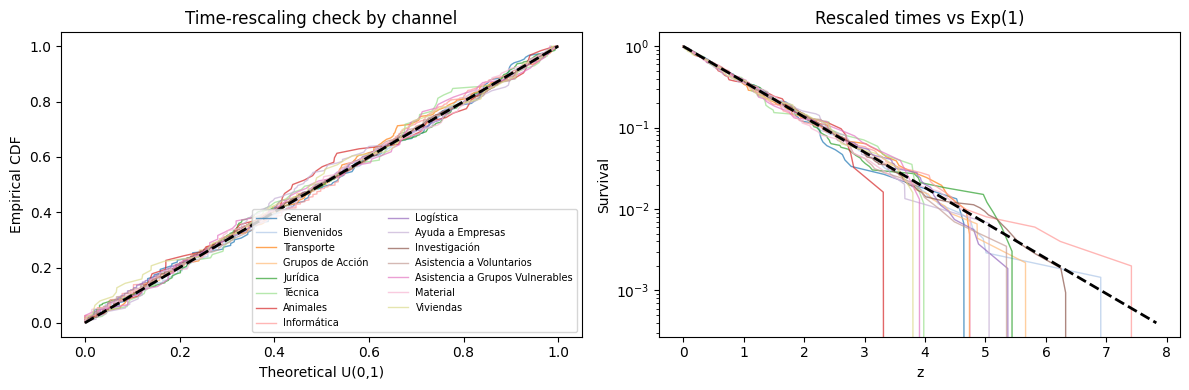

In [42]:
# Apply Time Rescaling Theorem to the waiting times of the different channels
from scipy.stats import kstest

# Containers
rescaling_results = {}
rescaling_summary_rows = []

for channel, waits in poll_waiting_times.items():
    tau = np.asarray(waits.values, dtype=float)
    tau = tau[np.isfinite(tau)]
    tau = tau[tau > 0]

    if tau.size < 100:
        print(f"Skipping {channel}: not enough data (n={tau.size})")
        continue

    # Fit TPL for this channel (same model used in previous cells)
    fit_ch = powerlaw.Fit(tau, discrete=False, verbose=False)
    tpl_ch = fit_ch.truncated_power_law
    xmin_ch = float(getattr(tpl_ch, "xmin", np.nan))

    # The theorem check is applied on the fitted tail
    tau_tail = tau[tau >= xmin_ch]
    if tau_tail.size < 30:
        print(f"Skipping {channel}: not enough tail data (n_tail={tau_tail.size})")
        continue

    # Probability integral transform: U = F(tau) should be Uniform(0,1)
    # Then z = -log(1-U) should be Exp(1)
    u = np.asarray(tpl_ch.cdf(tau_tail), dtype=float)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)

    ks_stat_u, ks_p_u = kstest(u, "uniform")
    ks_stat_z, ks_p_z = kstest(z, "expon")

    rescaling_results[channel] = {
        "u": u,
        "z": z,
        "ks_stat_uniform": float(ks_stat_u),
        "ks_p_uniform": float(ks_p_u),
        "ks_stat_exp1": float(ks_stat_z),
        "ks_p_exp1": float(ks_p_z),
        "n_tail": int(tau_tail.size),
        "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
        "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
        "xmin": xmin_ch,
    }

    rescaling_summary_rows.append(
        {
            "channel": channel,
            "n_tail": int(tau_tail.size),
            "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
            "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
            "xmin": xmin_ch,
            "KS_U(0,1)": float(ks_stat_u),
            "p_U(0,1)": float(ks_p_u),
            "KS_Exp(1)": float(ks_stat_z),
            "p_Exp(1)": float(ks_p_z),
        }
    )

# Summary table (safe even if empty)
rescaling_summary = pd.DataFrame(rescaling_summary_rows)
if not rescaling_summary.empty:
    rescaling_summary = rescaling_summary.sort_values(
        ["p_U(0,1)", "KS_U(0,1)"], ascending=[False, True]
    ).reset_index(drop=True)

print("Time-rescaling summary (higher p and lower KS are better):")
display(rescaling_summary)

# Optional pooled diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for channel, out in rescaling_results.items():
    u_sorted = np.sort(out["u"])
    ecdf = np.arange(1, len(u_sorted) + 1) / len(u_sorted)
    axes[0].plot(u_sorted, ecdf, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

axes[0].plot([0, 1], [0, 1], "k--", lw=2)
axes[0].set_xlabel("Theoretical U(0,1)")
axes[0].set_ylabel("Empirical CDF")
axes[0].set_title("Time-rescaling check by channel")

for channel, out in rescaling_results.items():
    z_sorted = np.sort(out["z"])
    surv = 1.0 - np.arange(1, len(z_sorted) + 1) / len(z_sorted)
    axes[1].plot(z_sorted, surv, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

z_max = max([np.max(v["z"]) for v in rescaling_results.values()], default=8)
z_grid = np.linspace(0, z_max, 200)
axes[1].plot(z_grid, np.exp(-z_grid), "k--", lw=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Survival")
axes[1].set_title("Rescaled times vs Exp(1)")

if 0 < len(rescaling_results) <= 10:
    axes[0].legend(fontsize=8)
elif len(rescaling_results) > 10:
    axes[0].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

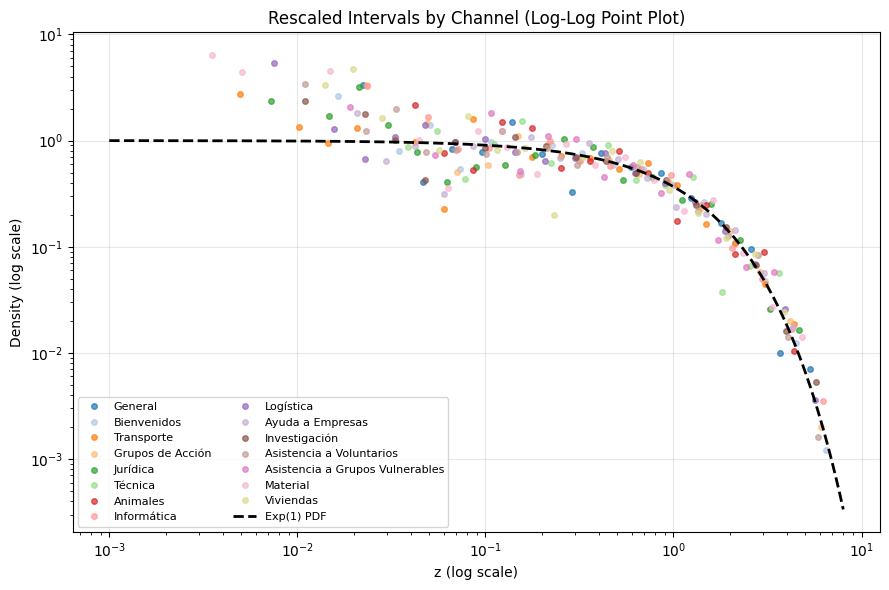

In [43]:
# Multi-channel version of the log-log rescaled-interval plot (point plot)
# Requires `rescaling_results` from the previous cell

plt.figure(figsize=(9, 6))

for channel, out in rescaling_results.items():
    z_channel = np.asarray(out["z"], dtype=float)
    z_channel = z_channel[np.isfinite(z_channel)]
    z_channel = z_channel[z_channel > 0]

    if z_channel.size < 30:
        continue

    # Log-binned empirical density (points)
    z_min = max(np.min(z_channel), 1e-3)
    z_max = np.max(z_channel)
    if z_max <= z_min:
        continue

    bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
    hist, edges = np.histogram(z_channel, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    mask = hist > 0
    plt.plot(centers[mask], hist[mask], marker='o', linestyle='none', ms=4, alpha=0.7, label=channel, color=channel_colors[channel])

# Theoretical Exp(1) density
x = np.logspace(-3, np.log10(max(8, np.max([np.max(v['z']) for v in rescaling_results.values()]))), 400)
plt.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=2, label='Exp(1) PDF')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('z (log scale)')
plt.ylabel('Density (log scale)')
plt.title('Rescaled Intervals by Channel (Log-Log Point Plot)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Time-Rescaling Theorem by Channel with data over 1000 messages

In [44]:
# Obtain the truncated power law fit for the waiting times of the different channels
poll_waiting_times = {
    'General': waiting_times_general,
    'Bienvenidos': waiting_times_bienvenidos,
    'Transporte': waiting_times_tranporte,
    'Grupos de Acción': waiting_times_grupos_accion,
    'Jurídica': waiting_times_juridica,
    'Técnica': waiting_times_tecnica,
    'Animales': waiting_times_animales,
    'Informática': waiting_times_informatica,
    'Logística': waiting_times_logistica,
    'Ayuda a Empresas': waiting_times_ayudaempresas,
    'Investigación': waiting_times_investigacion,
    'Asistencia a Voluntarios': waiting_times_asistencia_voluntarios,
    'Asistencia a Grupos Vulnerables': waiting_times_asistencia_vulnerables,
    'Material': waiting_times_material,
    'Webs': waiting_times_webs,
    'Mensajes de Ayuda': waiting_times_mensajes_ayuda,
    'Voluntarios de Fuera': waiting_times_voluntarios_fuera,
    'Viviendas': waiting_times_viviendas
}
results = {}
for channel, waits in poll_waiting_times.items():
    data = np.asarray(waits.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    if len(data) < 1000:
        print(f"Skipping {channel} (not enough data points)")
        continue
    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    tpl = fit.truncated_power_law
    results[channel] = {
        'alpha': getattr(tpl, "alpha", np.nan),
        'lambda': getattr(tpl, "Lambda", np.nan),
        'xmin': getattr(tpl, "xmin", np.nan),
        'sigma': getattr(tpl, "sigma", np.nan),
        'n_tail': int(np.sum(data >= getattr(tpl, "xmin", np.nan))),
        'n_total': len(data)
    }
    print(f"Finished fitting {channel} (n={len(data)})")
    print(f"  alpha: {results[channel]['alpha']:.4f}, lambda: {results[channel]['lambda']:.6f}, xmin: {results[channel]['xmin']:.4f}, sigma: {results[channel]['sigma']:.4f}")





Skipping General (not enough data points)
Finished fitting Bienvenidos (n=2615)
  alpha: 2.0788, lambda: 0.000015, xmin: 72.0000, sigma: nan
Finished fitting Transporte (n=1974)
  alpha: 1.9051, lambda: 0.000009, xmin: 541.0000, sigma: nan
Skipping Grupos de Acción (not enough data points)
Skipping Jurídica (not enough data points)
Skipping Técnica (not enough data points)
Skipping Animales (not enough data points)
Finished fitting Informática (n=1914)
  alpha: 2.1893, lambda: 0.000000, xmin: 42.0000, sigma: nan
Finished fitting Logística (n=1188)
  alpha: 1.5041, lambda: 0.000035, xmin: 64.0000, sigma: nan
Skipping Ayuda a Empresas (not enough data points)
Finished fitting Investigación (n=2625)
  alpha: 1.6858, lambda: 0.000034, xmin: 54.0000, sigma: nan
Finished fitting Asistencia a Voluntarios (n=1128)
  alpha: 1.8890, lambda: 0.000039, xmin: 89.0000, sigma: nan
Skipping Asistencia a Grupos Vulnerables (not enough data points)
Skipping Material (not enough data points)
Skipping Web

Skipping Webs: not enough data (n=12)
Skipping Mensajes de Ayuda: not enough data (n=3)
Skipping Voluntarios de Fuera: not enough data (n=4)
Time-rescaling summary (higher p and lower KS are better):


,channel,n_tail,alpha,lambda,xmin,"KS_U(0,1)","p_U(0,1)",KS_Exp(1),p_Exp(1)
0,General,150,1.593995,4.093386e-05,31.0,0.034598,0.991184,0.034598,0.991184
1,Material,123,1.822575,2.027832e-05,1040.0,0.038405,0.990332,0.038405,0.990332
2,Asistencia a Grupos Vulnerables,76,1.520704,8.326323e-04,42.0,0.050387,0.985251,0.050387,0.985251
3,Asistencia a Voluntarios,287,1.889023,3.904220e-05,89.0,0.027365,0.978670,0.027365,0.978670
4,Viviendas,63,1.913442,1.475663e-05,1587.0,0.066235,0.927865,0.066235,0.927865
5,Bienvenidos,690,2.078786,1.462642e-05,72.0,0.022834,0.856229,0.022834,0.856229
6,Logística,538,1.504061,3.524968e-05,64.0,0.027150,0.812225,0.027150,0.812225
7,Investigación,1063,1.685781,3.410502e-05,54.0,0.019387,0.811678,0.019387,0.811678
8,Grupos de Acción,457,1.817951,2.444141e-04,32.0,0.029866,0.798090,0.029866,0.798090
9,Animales,62,1.922993,3.623201e-05,1114.0,0.080503,0.786463,0.080503,0.786463


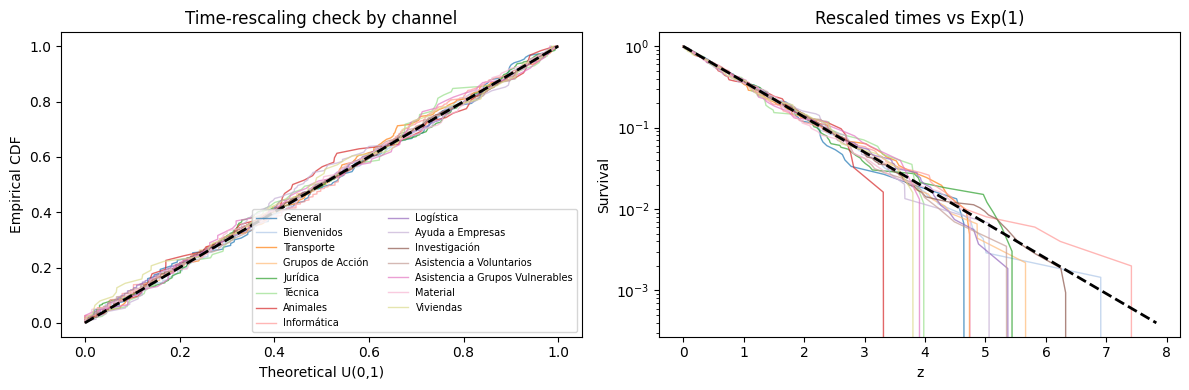

In [45]:
# Apply Time Rescaling Theorem to the waiting times of the different channels
from scipy.stats import kstest

# Containers
rescaling_results = {}
rescaling_summary_rows = []

for channel, waits in poll_waiting_times.items():
    tau = np.asarray(waits.values, dtype=float)
    tau = tau[np.isfinite(tau)]
    tau = tau[tau > 0]

    if tau.size < 100:
        print(f"Skipping {channel}: not enough data (n={tau.size})")
        continue

    # Fit TPL for this channel (same model used in previous cells)
    fit_ch = powerlaw.Fit(tau, discrete=False, verbose=False)
    tpl_ch = fit_ch.truncated_power_law
    xmin_ch = float(getattr(tpl_ch, "xmin", np.nan))

    # The theorem check is applied on the fitted tail
    tau_tail = tau[tau >= xmin_ch]
    if tau_tail.size < 30:
        print(f"Skipping {channel}: not enough tail data (n_tail={tau_tail.size})")
        continue

    # Probability integral transform: U = F(tau) should be Uniform(0,1)
    # Then z = -log(1-U) should be Exp(1)
    u = np.asarray(tpl_ch.cdf(tau_tail), dtype=float)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)

    ks_stat_u, ks_p_u = kstest(u, "uniform")
    ks_stat_z, ks_p_z = kstest(z, "expon")

    rescaling_results[channel] = {
        "u": u,
        "z": z,
        "ks_stat_uniform": float(ks_stat_u),
        "ks_p_uniform": float(ks_p_u),
        "ks_stat_exp1": float(ks_stat_z),
        "ks_p_exp1": float(ks_p_z),
        "n_tail": int(tau_tail.size),
        "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
        "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
        "xmin": xmin_ch,
    }

    rescaling_summary_rows.append(
        {
            "channel": channel,
            "n_tail": int(tau_tail.size),
            "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
            "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
            "xmin": xmin_ch,
            "KS_U(0,1)": float(ks_stat_u),
            "p_U(0,1)": float(ks_p_u),
            "KS_Exp(1)": float(ks_stat_z),
            "p_Exp(1)": float(ks_p_z),
        }
    )

# Summary table (safe even if empty)
rescaling_summary = pd.DataFrame(rescaling_summary_rows)
if not rescaling_summary.empty:
    rescaling_summary = rescaling_summary.sort_values(
        ["p_U(0,1)", "KS_U(0,1)"], ascending=[False, True]
    ).reset_index(drop=True)

print("Time-rescaling summary (higher p and lower KS are better):")
display(rescaling_summary)

# Optional pooled diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for channel, out in rescaling_results.items():
    u_sorted = np.sort(out["u"])
    ecdf = np.arange(1, len(u_sorted) + 1) / len(u_sorted)
    axes[0].plot(u_sorted, ecdf, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

axes[0].plot([0, 1], [0, 1], "k--", lw=2)
axes[0].set_xlabel("Theoretical U(0,1)")
axes[0].set_ylabel("Empirical CDF")
axes[0].set_title("Time-rescaling check by channel")

for channel, out in rescaling_results.items():
    z_sorted = np.sort(out["z"])
    surv = 1.0 - np.arange(1, len(z_sorted) + 1) / len(z_sorted)
    axes[1].plot(z_sorted, surv, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

z_max = max([np.max(v["z"]) for v in rescaling_results.values()], default=8)
z_grid = np.linspace(0, z_max, 200)
axes[1].plot(z_grid, np.exp(-z_grid), "k--", lw=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Survival")
axes[1].set_title("Rescaled times vs Exp(1)")

if 0 < len(rescaling_results) <= 10:
    axes[0].legend(fontsize=8)
elif len(rescaling_results) > 10:
    axes[0].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

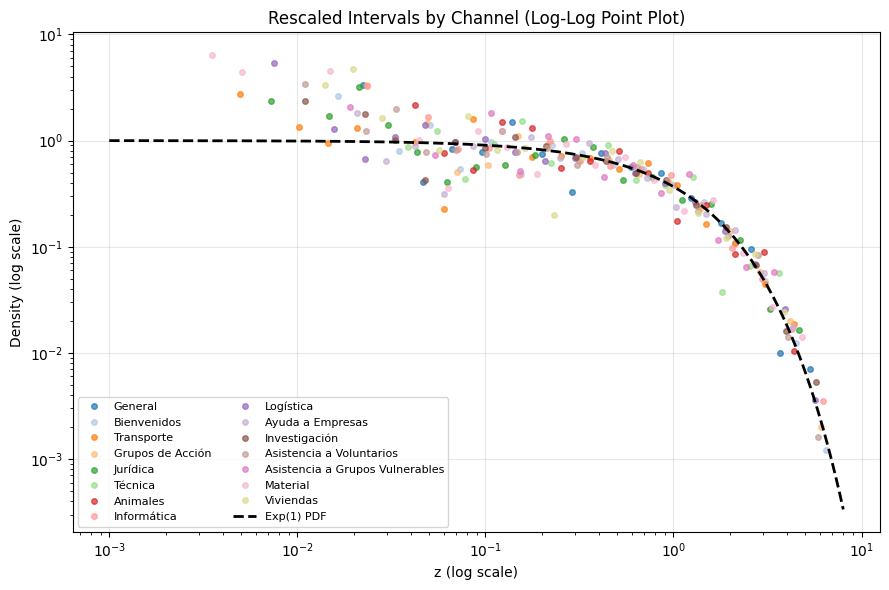

In [46]:
# Multi-channel version of the log-log rescaled-interval plot (point plot)
# Requires `rescaling_results` from the previous cell

plt.figure(figsize=(9, 6))

for channel, out in rescaling_results.items():
    z_channel = np.asarray(out["z"], dtype=float)
    z_channel = z_channel[np.isfinite(z_channel)]
    z_channel = z_channel[z_channel > 0]

    if z_channel.size < 30:
        continue

    # Log-binned empirical density (points)
    z_min = max(np.min(z_channel), 1e-3)
    z_max = np.max(z_channel)
    if z_max <= z_min:
        continue

    bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
    hist, edges = np.histogram(z_channel, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    mask = hist > 0
    plt.plot(centers[mask], hist[mask], marker='o', linestyle='none', ms=4, alpha=0.7, label=channel, color=channel_colors[channel])

# Theoretical Exp(1) density
x = np.logspace(-3, np.log10(max(8, np.max([np.max(v['z']) for v in rescaling_results.values()]))), 400)
plt.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=2, label='Exp(1) PDF')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('z (log scale)')
plt.ylabel('Density (log scale)')
plt.title('Rescaled Intervals by Channel (Log-Log Point Plot)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()